In [1]:
import os
import yaml

print("🔍 Searching for your dataset...")

# 1. Dynamically find where Kaggle put your d2s.yaml file
yaml_found = False
for root, dirs, files in os.walk("/kaggle/input"):
    if "d2s.yaml" in files:
        old_yaml_path = os.path.join(root, "d2s.yaml")
        kaggle_dataset_path = root
        yaml_found = True
        break

if not yaml_found:
    print("🚨 ERROR: Could not find d2s.yaml! Make sure you clicked 'Add Data' on the right sidebar.")
else:
    print(f"✅ Found dataset at: {kaggle_dataset_path}")
    
    # 2. Fix the YAML file to use Kaggle paths instead of Google Drive paths
    new_yaml_path = "/kaggle/working/d2s_kaggle.yaml"
    with open(old_yaml_path, 'r') as f:
        config = yaml.safe_load(f)

    config['path'] = kaggle_dataset_path

    with open(new_yaml_path, 'w') as f:
        yaml.dump(config, f, default_flow_style=False, sort_keys=False)
        
    print("✅ YAML paths successfully updated for Kaggle!")

    # 3. Install YOLO directly in the notebook
    print("📦 Installing Ultralytics YOLOv8...")
    !pip install ultralytics -q
    print("✅ Installation complete!")

    # 4. Start the 100-epoch training run!
    print("🚀 STARTING TRAINING...")
    !yolo train model=yolov8n-seg.pt data={new_yaml_path} epochs=100 batch=16 imgsz=640 device=0

🔍 Searching for your dataset...
✅ Found dataset at: /kaggle/input/datasets/muzzammilidrees/mvtecd2s/mvtec_d2s_yolo
✅ YAML paths successfully updated for Kaggle!
📦 Installing Ultralytics YOLOv8...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 34.2 MB/s eta 0:00:0000:01
✅ Installation complete!
🚀 STARTING TRAINING...
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.47 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, c

🔍 Searching Kaggle folders for test images...
✅ Found an image! Testing model on: /kaggle/input/datasets/muzzammilidrees/mvtecd2s/mvtec_d2s_yolo/images/val/D2S_058609.jpg

image 1/1 /kaggle/input/datasets/muzzammilidrees/mvtecd2s/mvtec_d2s_yolo/images/val/D2S_058609.jpg: 480x640 1 apple_golden_delicious, 1 banana_bundle, 53.0ms
Speed: 4.2ms preprocess, 53.0ms inference, 58.3ms postprocess per image at shape (1, 3, 480, 640)
Results saved to /kaggle/working/runs/segment/predict


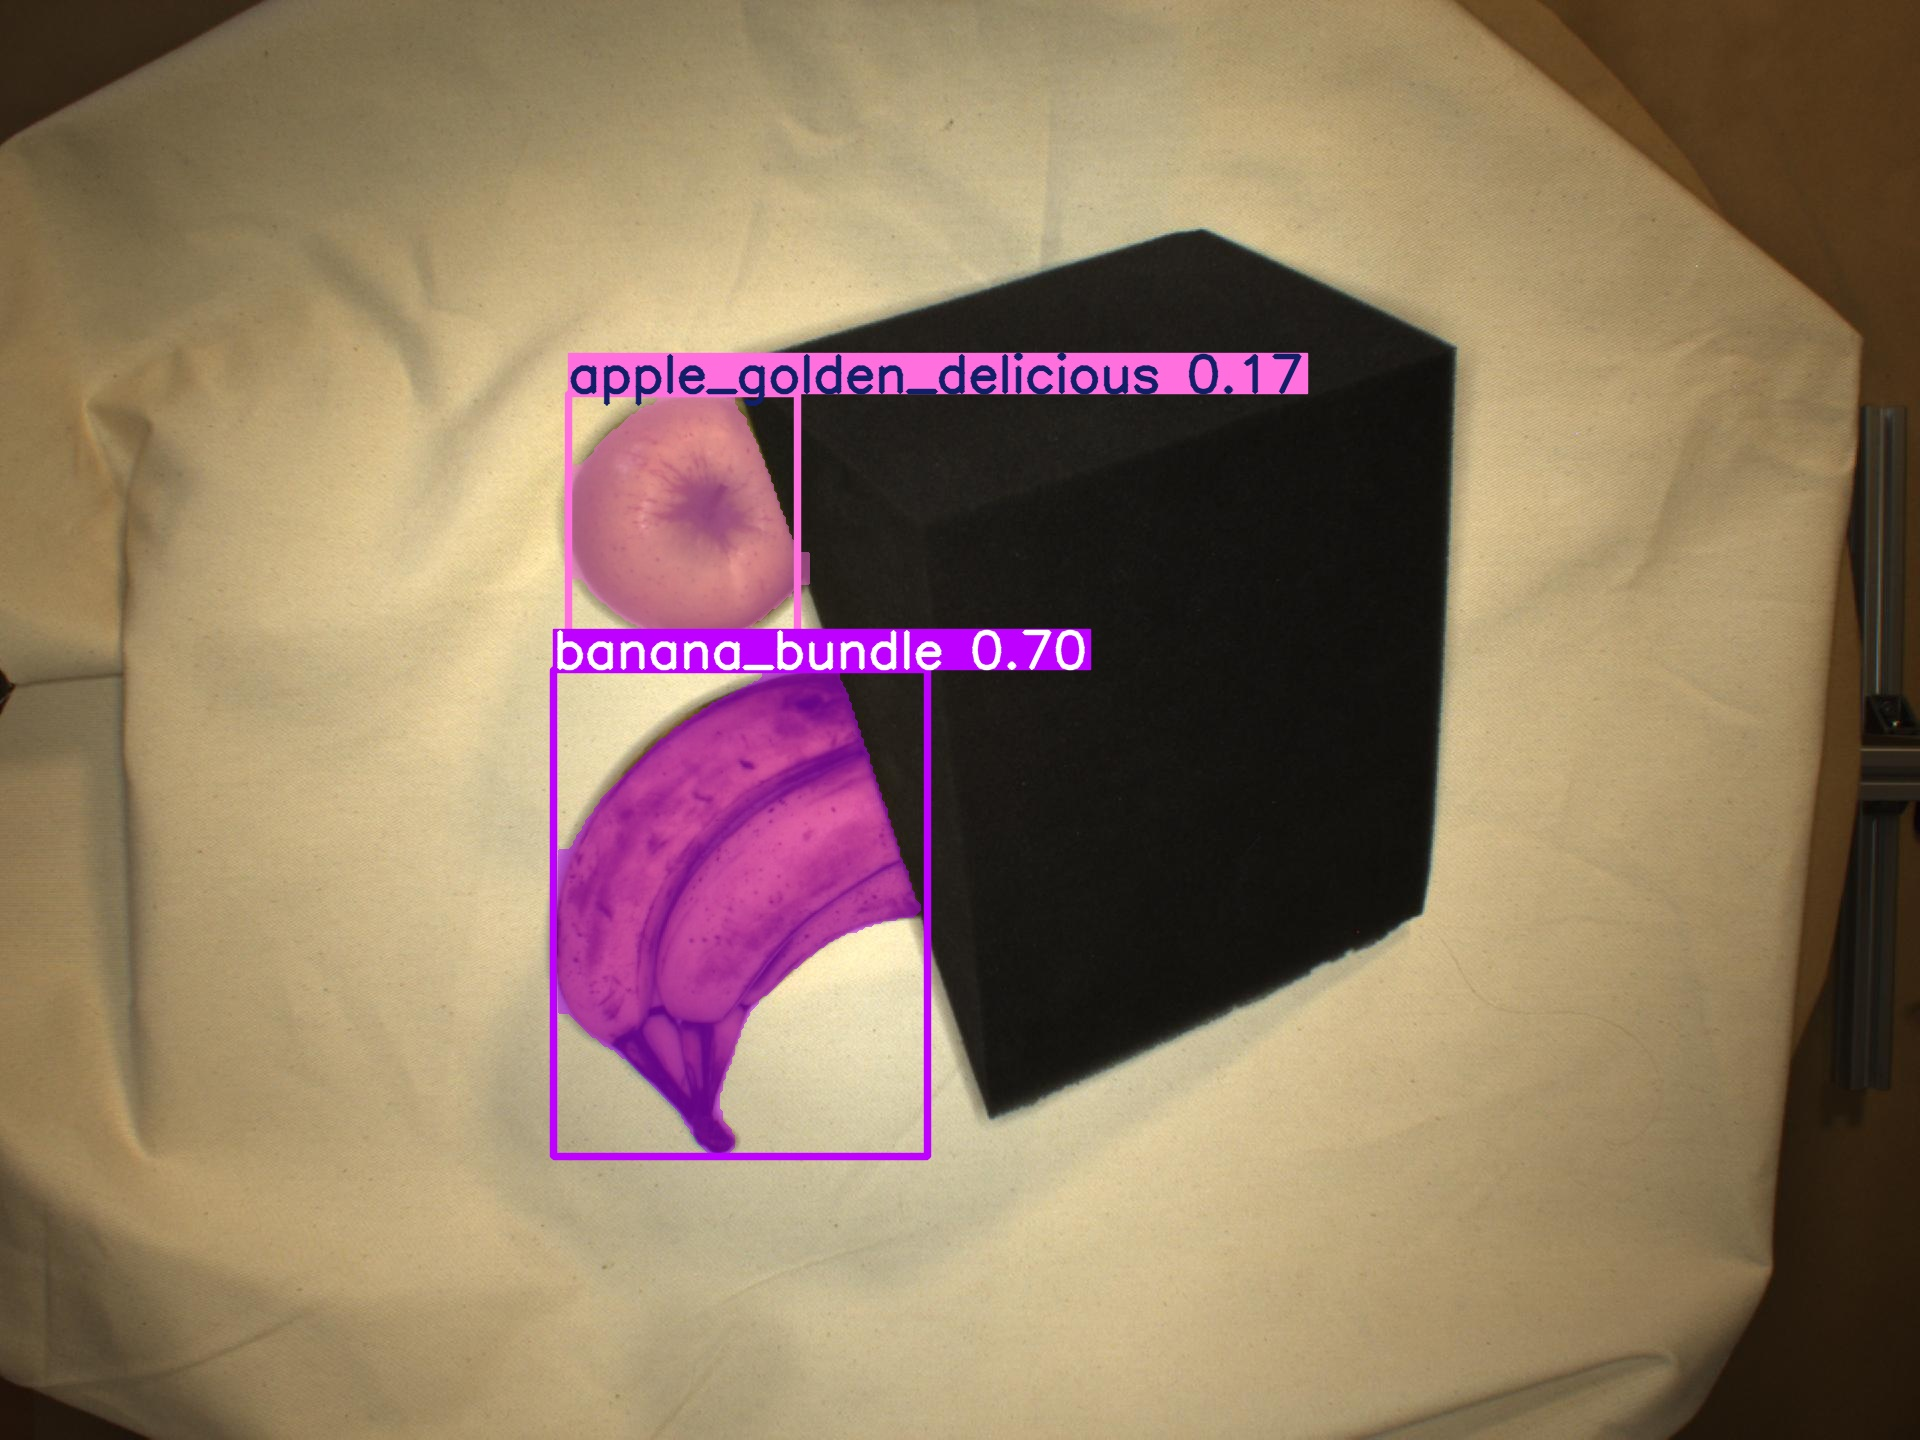

In [2]:
import os
from ultralytics import YOLO
from IPython.display import Image, display

# 1. Point YOLO directly to your freshly trained brain
model = YOLO("/kaggle/working/runs/segment/train/weights/best.pt")

# 2. Bulletproof way to find a validation image
print("🔍 Searching Kaggle folders for test images...")
test_images = []
for root, dirs, files in os.walk("/kaggle/input"):
    # We only want images from your validation folder
    if "images" in root and "val" in root: 
        for file in files:
            if file.endswith(".jpg"):
                test_images.append(os.path.join(root, file))

if not test_images:
    print("🚨 Uh oh, couldn't find any JPG images! Check your dataset structure.")
else:
    # Grab the very first image it found
    my_test_image = test_images[0] 
    print(f"✅ Found an image! Testing model on: {my_test_image}")

    # 3. Run the prediction! (save=True tells it to draw the polygons)
    results = model.predict(source=my_test_image, save=True , conf = 0.15)

    # 4. Display the beautiful result right here in the notebook
    predicted_image_path = results[0].save_dir + "/" + my_test_image.split('/')[-1]
    display(Image(filename=predicted_image_path))

In [3]:
import os
import yaml
from ultralytics import YOLO

print("🔍 Searching for your dataset...")

# 1. Dynamically find where Kaggle put your d2s.yaml file
yaml_found = False
for root, dirs, files in os.walk("/kaggle/input"):
    if "d2s.yaml" in files:
        old_yaml_path = os.path.join(root, "d2s.yaml")
        kaggle_dataset_path = root
        yaml_found = True
        break

if not yaml_found:
    print("🚨 ERROR: Could not find d2s.yaml! Make sure your dataset is attached.")
else:
    print(f"✅ Found dataset at: {kaggle_dataset_path}")
    
    # 2. Re-create the fixed YAML file for Kaggle
    new_yaml_path = "/kaggle/working/d2s_kaggle.yaml"
    with open(old_yaml_path, 'r') as f:
        config = yaml.safe_load(f)

    config['path'] = kaggle_dataset_path

    with open(new_yaml_path, 'w') as f:
        yaml.dump(config, f, default_flow_style=False, sort_keys=False)
        
    print("✅ YAML map successfully re-created!")

    # 3. Load the model and start training
    print("📦 Loading the YOLOv8 Small model...")
    model = YOLO("yolov8s-seg.pt")

    print("🚀 Starting the Overfit-Buster training run...")
    results = model.train(
        data=new_yaml_path,
        epochs=100,
        batch=16,
        imgsz=640,
        device=0,
        patience=25,       # Stop early if it stops improving
        degrees=25.0,      # Rotate images randomly
        mixup=0.2,         # Blend two images together
        copy_paste=0.3,    # Copy/paste segmented objects
        flipud=0.5         # Flip upside down
    )

    print("✅ Training complete!")

🔍 Searching for your dataset...
✅ Found dataset at: /kaggle/input/datasets/muzzammilidrees/mvtecd2s/mvtec_d2s_yolo
✅ YAML map successfully re-created!
📦 Loading the YOLOv8 Small model...
🚀 Starting the Overfit-Buster training run...
Ultralytics 8.4.47 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.3, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/d2s_kaggle.yaml, degrees=25.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.

📦 Loading most recent model from: /kaggle/working/runs/segment/train/weights/best.pt

📊 RUNNING OFFICIAL VALIDATION TESTS...
Ultralytics 8.4.47 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8n-seg summary (fused): 86 layers, 3,269,764 parameters, 0 gradients, 11.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 376.0±69.0 MB/s, size: 234.2 KB)
val: Scanning /kaggle/input/datasets/muzzammilidrees/mvtecd2s/mvtec_d2s_yolo/labels/val... 1350 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1350/1350 410.9it/s 3.3s<0.0s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/muzzammilidrees/mvtecd2s/mvtec_d2s_yolo/labels is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 85/85 4.8it/s 17.7s0.2s
                   all       1350       6621      0.569      0.344      0.376      0.325      0.564      0.342      0.373      0.315

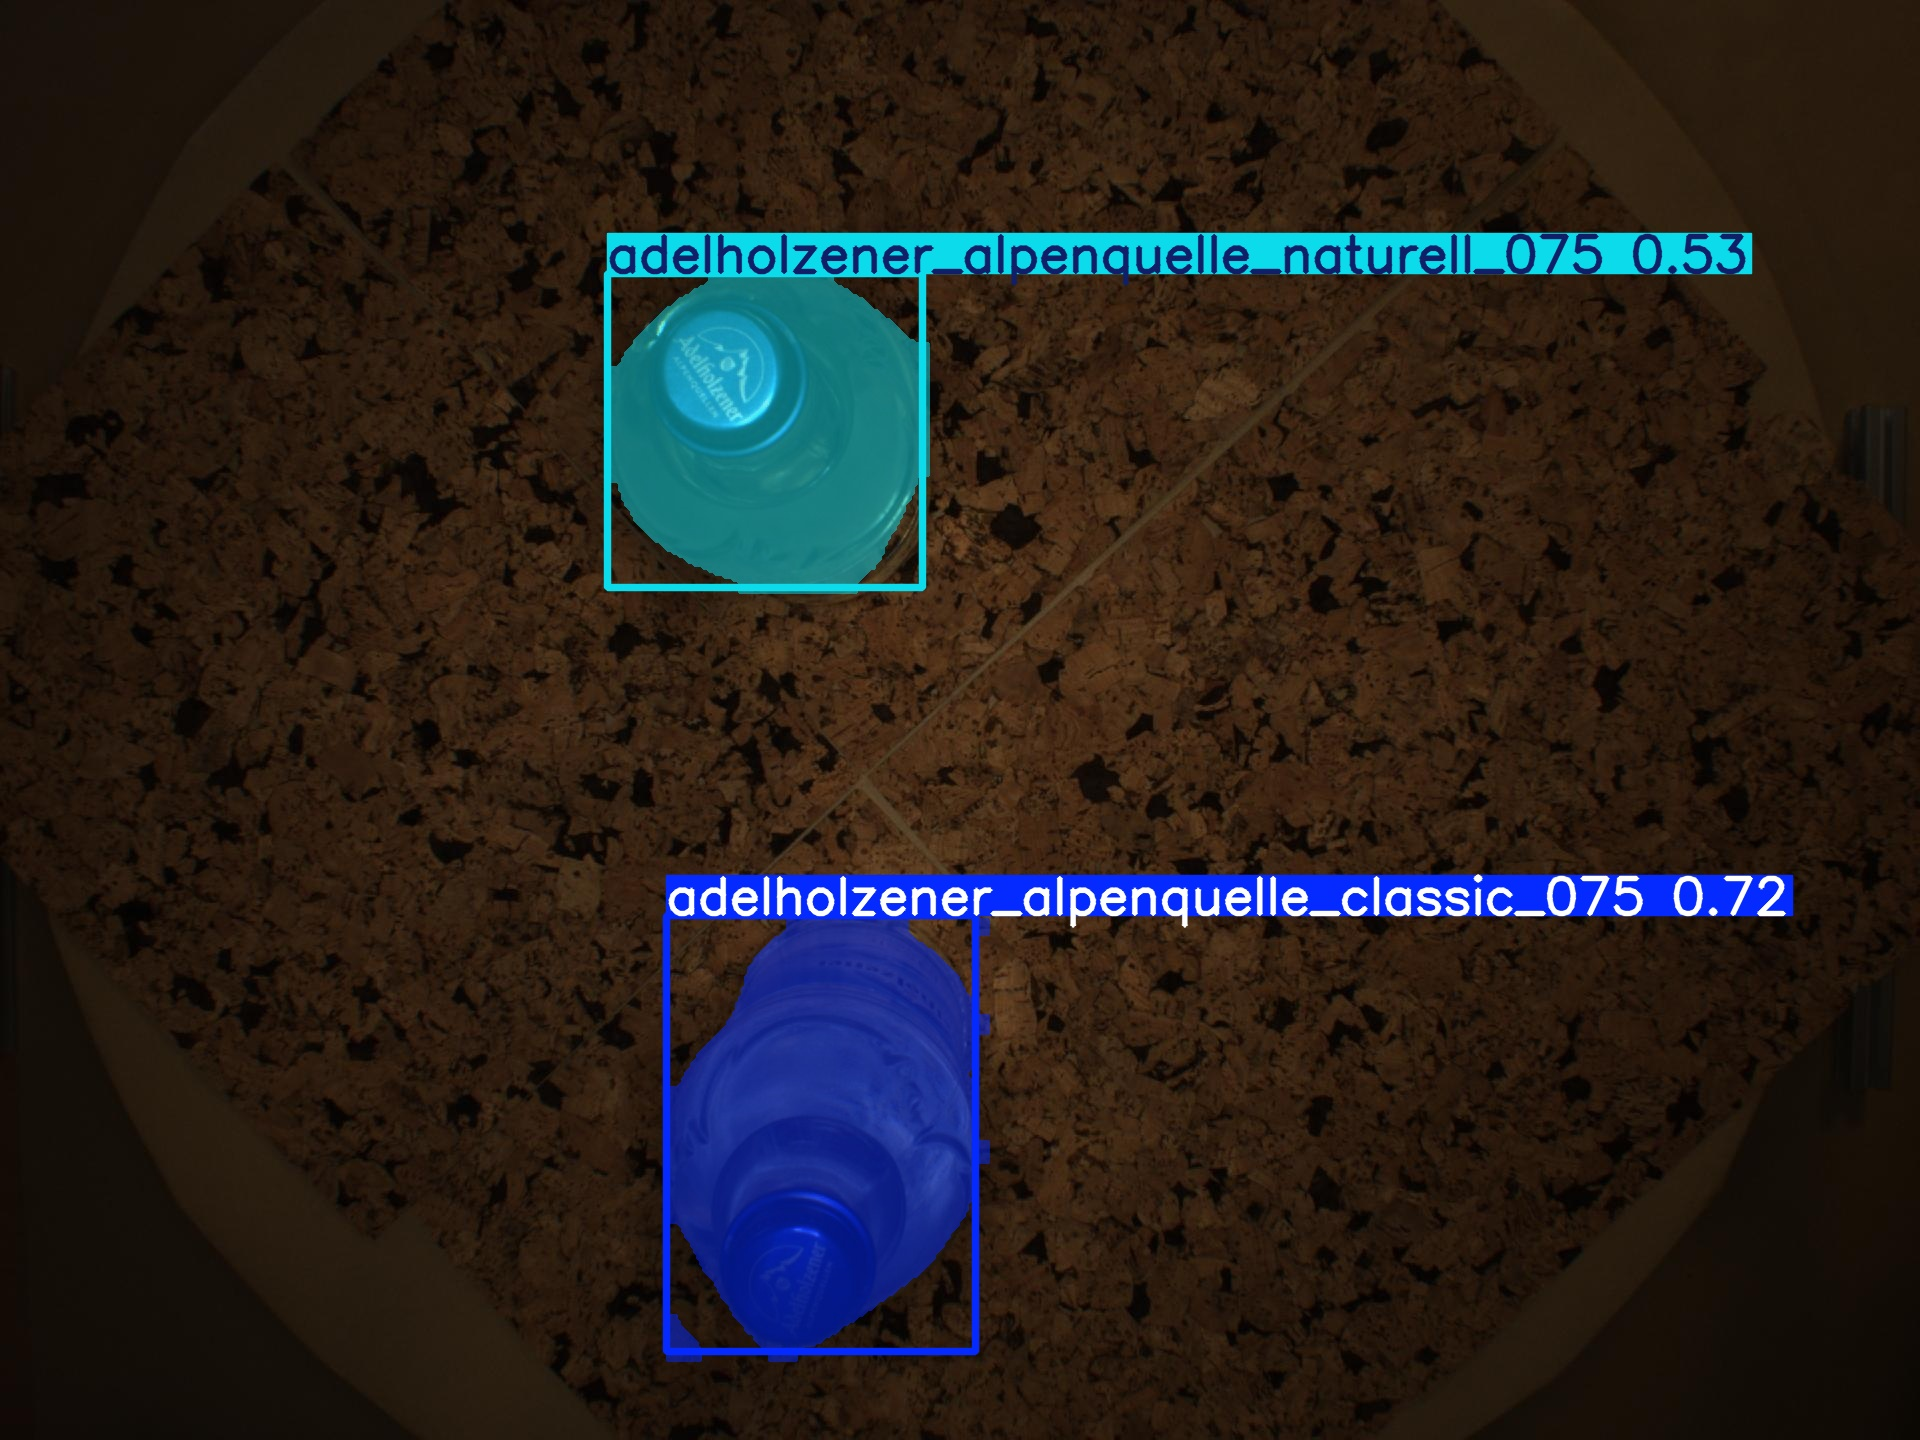

In [4]:
import os
import glob
from ultralytics import YOLO
from IPython.display import Image, display

# 1. Automatically find the LATEST best.pt in the working directory
# This looks for any folder inside runs/segment/ and picks the newest weights
weight_files = glob.glob("/kaggle/working/runs/segment/*/weights/best.pt")

if not weight_files:
    print("🚨 ERROR: Could not find any trained weights! Check if 'runs' folder exists in the Output tab on the right.")
else:
    # Sort them and pick the last one (the most recent training run)
    model_path = sorted(weight_files)[-1]
    print(f"📦 Loading most recent model from: {model_path}")
    model = YOLO(model_path)

    print("\n📊 RUNNING OFFICIAL VALIDATION TESTS...")
    metrics = model.val()
    print(f"\n✅ Final Mask mAP@50: {metrics.seg.map50:.3f}")
    print(f"✅ Final Box mAP@50: {metrics.box.map50:.3f}")

    print("\n🖼️ RUNNING VISUAL TEST ON A SAMPLE IMAGE...")
    # Find a validation image
    test_images = []
    for root, dirs, files in os.walk("/kaggle/input"):
        if "images" in root and "val" in root: 
            for file in files:
                if file.endswith(".jpg"):
                    test_images.append(os.path.join(root, file))

    if test_images:
        my_test_image = test_images[15] # Grab a different image this time!
        results = model.predict(source=my_test_image, save=True, conf=0.50)

        # Display the result
        predicted_image_path = os.path.join(results[0].save_dir, my_test_image.split('/')[-1])
        print(f"\n✨ VISUAL TEST RESULT (Confidence > 0.50):")
        display(Image(filename=predicted_image_path))
    else:
        print("🚨 Could not find any validation images.")